---
date: "2026-07-28"
date-modified: last-modified
format:
  html:
    toc: true
---


# Time Series Returns

## 1\. Introduction to Asset Returns

In financial time series analysis, we usually study the returns of an asset rather than its prices. Returns have better statistical properties than prices, such as scale-freeness and [stationarity](autocorrelation-and-stationarity.ipynb). 

::: {#def-asset-price}
## Asset Price
Let $P_t$ denote the price of an asset at time index $t$.
:::

## 2\. Simple Return

### 2.1\. One Period Simple Return

If you purchase an asset at time $t-1$ for $P_{t-1}$ and sell it at time $t$ for $P_t$, your return consists of the capital gain and any dividend payments. Ignoring dividends for simplicity, we define the following concepts:

::: {#def-gross-return}
## Gross Return
The **gross return** from time $t-1$ to time $t$ is:
$$
1 + R_t = \frac{P_t}{P_{t-1}}
$$
:::

::: {#def-simple-return}
## Simple Return (Net Return)
The one-period **simple return** is:
$$
R_t = \frac{P_t}{P_{t-1}} - 1 = \frac{P_t - P_{t-1}}{P_{t-1}}
$$
:::

### 2.2\. Multi-period Simple Return

If you hold the asset for $k$ periods, from time $t-k$ to time $t$, the $k$-period simple return is computed by compounding the single-period returns.

::: {#def-multiperiod-return}
## Multi-period Simple Return
The gross $k$-period simple return is:
$$
1 + R_{t[k]} = \frac{P_t}{P_{t-k}} = \frac{P_t}{P_{t-1}} \times \frac{P_{t-1}}{P_{t-2}} \times \dots \times \frac{P_{t-k+1}}{P_{t-k}}
$$
This is equivalent to the product of one-period gross returns:
$$
1 + R_{t[k]} = \prod_{j=0}^{k-1} (1 + R_{t-j})
$$
:::

### 2.3\. Annualized Return

To compare returns over different holding periods (e.g., holding an asset for $k$ years), it is common practice to present them in annualized terms.

::: {#def-annualized-return}
## Annualized Return
For an asset held for $k$ years, the equivalent annual return $R$ is given by:
$$
(1 + R)^k = 1 + R_{t[k]} \implies R = \left( 1 + R_{t[k]} \right)^{1/k} - 1
$$
Alternatively, it can be calculated as:
$$
R = \exp \left( \frac{1}{k} \sum_{j=0}^{k-1} \ln(1 + R_{t-j}) \right) - 1
$$
:::

::: {.callout-tip collapse="true"}
## Derivation of Annualized Return using Exponential
Starting from the geometric mean definition:
$$
\begin{aligned}
(1 + R) &= \left( \prod_{j=0}^{k-1} (1 + R_{t-j}) \right)^{1/k} \\
\ln(1 + R) &= \frac{1}{k} \sum_{j=0}^{k-1} \ln(1 + R_{t-j}) \\
1 + R &= \exp \left( \frac{1}{k} \sum_{j=0}^{k-1} \ln(1 + R_{t-j}) \right) \\
R &= \exp \left( \frac{1}{k} \sum_{j=0}^{k-1} \ln(1 + R_{t-j}) \right) - 1 \quad \blacksquare
\end{aligned}
$$
:::

## 3\. Continuously Compounded (Log) Return

In banking, interest can be compounded over different frequencies (e.g., monthly, daily). 
- Monthly compounding rate: $(1 + \frac{R}{12})^{12}$
- Daily compounding rate: $(1 + \frac{R}{365})^{365}$

As the compounding frequency goes to infinity, we get the continuous compounding rate.

::: {#thm-continuous-compounding}
## Limit of Continuous Compounding
The limit of the compound interest formula as the number of periods $n$ goes to infinity is:
$$
\lim_{n \to \infty} \left( 1 + \frac{R}{n} \right)^n = e^R
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Continuous Compounding Limit
Let $x = \lim_{n \to \infty} \left( 1 + \frac{R}{n} \right)^n$. Because the natural logarithm is continuous, we can find the limit of $\ln x$:
$$
\ln x = \lim_{n \to \infty} n \ln\left( 1 + \frac{R}{n} \right) = \lim_{n \to \infty} \frac{\ln\left( 1 + \frac{R}{n} \right)}{1/n}
$$
Applying L'Hopital's Rule to the limit of the indeterminate form $0/0$:
$$
\lim_{n \to \infty} \frac{ \frac{1}{1 + R/n} \cdot \left( -\frac{R}{n^2} \right) }{ -1/n^2 } = \lim_{n \to \infty} \frac{R}{1 + R/n} = R
$$
Since $\ln x = R$, taking the exponential gives:
$$
x = e^R \quad \blacksquare
$$
:::

::: {#def-log-return}
## Log Return
If we denote $r$ as the continuously compounded return equivalent to simple return $R$, then $1 + R = e^r$. We define the **log return** $r_t$ as:
$$
r_t = \ln(1 + R_t) = \ln \left( \frac{P_t}{P_{t-1}} \right) = \ln P_t - \ln P_{t-1}
$$
:::

### 3.1\. Advantages of Log Return

1. **Comparability:** Allows comparison with continuously compounded banking interest rates.
2. **Additivity:** Multi-period log returns are simply the sum of single-period log returns (unlike simple returns which are multiplicative).
3. **Approximation:** For small values of $R$, the log return is approximately equal to the simple return.

::: {.callout-note}
## Intuition: Log Return Approximation
By the Taylor series expansion of $\ln(1+x)$ around $x=0$, we have $\ln(1+R) \approx R$ for very small $R$. Thus, for small variations in asset prices, simple returns and log returns are numerically very close.
:::

## 4\. Portfolio Return and Distribution Statistics

### 4.1\. Portfolio Return

If you hold $N$ assets with weights $w_i$ (where $\sum w_i = 1$), the simple return of the portfolio $R_{p,t}$ is a linear combination of the individual simple returns:

$$
R_{p,t} = \sum_{i=1}^N w_i R_{it}
$$

For log returns, the exact linear combination does not hold, but it is often approximated for simplicity in practice:

$$
r_{p,t} \approx \sum_{i=1}^N w_i r_{it}
$$

### 4.2\. Skewness and Kurtosis

When analyzing the distribution of returns, two important statistical moments characterize their shape:

- **Skewness:** Measures the asymmetry of the distribution.
  - *Positive Skewness (Right-skewed):* Distribution has a long right tail, indicating a higher probability of large positive returns.
  - *Negative Skewness (Left-skewed):* Distribution has a long left tail, indicating a higher probability of large negative returns.
- **Kurtosis:** Measures the "fatness" of the tails.
  - Empirical financial data often exhibits *positive excess kurtosis* (leptokurtic). This means the returns have fatter tails than a normal distribution, implying that extreme events (large price swings) happen more frequently than a normal distribution would predict.

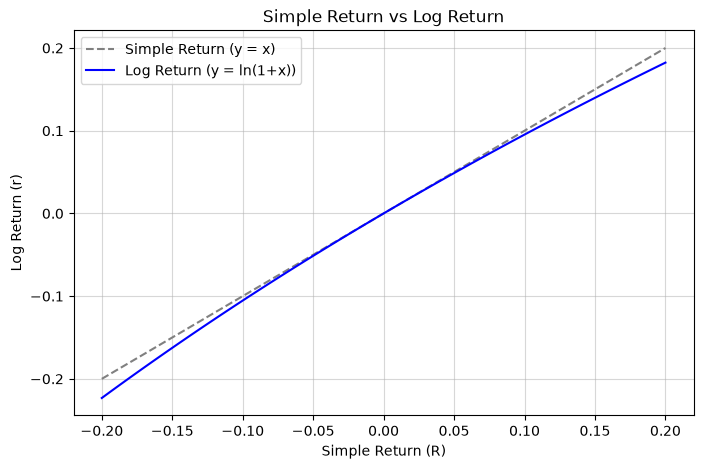

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Comparison of Simple Return and Log Return
R = np.linspace(-0.2, 0.2, 100)
r = np.log(1 + R)

plt.figure(figsize=(8, 5))
plt.plot(R, R, label='Simple Return (y = x)', linestyle='--', color='gray')
plt.plot(R, r, label='Log Return (y = ln(1+x))', color='blue')
plt.title("Simple Return vs Log Return")
plt.xlabel("Simple Return (R)")
plt.ylabel("Log Return (r)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


> **References & Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay.